# 1. Import and Install Dependencies

## 1.2 Load Dependencies

In [146]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
from split_audio_by_duration import split_audio_by_duration 

In [147]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

print(tf.test.gpu_device_name())
print(tf.config.get_visible_devices())

Num GPUs Available:  0
False

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


# 2. Build Data Loading Function

## 2.1 Define Paths to Files

In [149]:
POSITIVE_FILE = os.path.join('audios', 'positive', '0.wav')
NEGATIVE_FILE = os.path.join('audios', 'negative', '0.wav')


In [150]:
file_contents = tf.io.read_file(POSITIVE_FILE)
file_contents

<tf.Tensor: shape=(), dtype=string, numpy=b'RIFF$\xfa\x00\x00WAVEfmt \x10\x00\x00\x00\x01\x00\x02\x00\x80>\x00\x00\x00\xfa\x00\x00\x04\x00\x10\x00data\x00\xfa\x00\x00\x1c\x1b\x1c\x1b\x1c\x1b\x1c\x1b(\x08(\x08h\x06h\x06\x19\xd6\x19\xd6\xfd\xd7\xfd\xd7z\x18z\x18z\x18z\x18\x8e\x1c\x8e\x1c\\\x1a\\\x1aN0N0N0N0Y-Y-Y-Y-*:*:*:*:5Z5Z5Z5Zt\xbdt\xbdt\xbdt\xbd\x03\xe7\x03\xe7\xf9\xe7\xf9\xe7\x16\xf2\x16\xf2E\xf2E\xf2\x1a\xa1\x1a\xa1\xdb\xa1\xdb\xa1[\xc2[\xc2\x18\xc2\x18\xc2\x0b\xdc\x0b\xdc\xeb\xdb\xeb\xdbN+N+o+o+q\x03q\x03t\x03t\x03\xb0\x1a\xb0\x1a\xbe\x1a\xbe\x1a{\xe7{\xe7{\xe7{\xe7\xe3\xd2\xe3\xd2\xa6\xd2\xa6\xd2\xdf\xe5\xdf\xe5\xdf\xe5\xdf\xe5S\xc6S\xc6S\xc6S\xc6\xb8\xcd\xb8\xcd\xb8\xcd\xb8\xcd\xce\xc7\xce\xc7\xce\xc7\xce\xc7\xcc0\xcc0\xcc0\xcc0\xb0\xf2\xb0\xf2\xb0\xf2\xb0\xf2\x85\xdb\x85\xdb\x85\xdb\x85\xdb\xca\xeb\xca\xeb\xca\xeb\xca\xeb\x94\xd7\x94\xd7\x94\xd7\x94\xd72\x152\x152\x152\x15l\xbfl\xbfl\xbfl\xbf\x94\xb4\x94\xb4\x94\xb4\x94\xb4\x93\x1d\x93\x1d\x93\x1d\x93\x1d]\t]\t]\t]\th\xe3h\xe3

In [151]:
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
sample_rate

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

## 2.2 Build Dataloading Function

In [152]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    # wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

## 2.3 Plot Wave

In [153]:
wave = load_wav_16k_mono(POSITIVE_FILE)
nwave = load_wav_16k_mono(NEGATIVE_FILE)

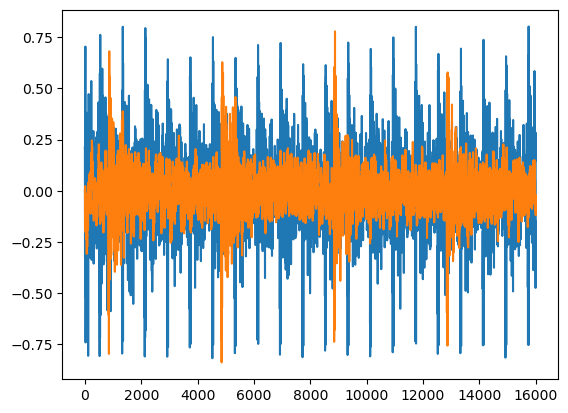

In [154]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

# 3. Create Tensorflow Dataset

## 3.1 Define Paths to Positive and Negative Data

In [155]:
POS = os.path.join('./', 'audios', 'positive')
NEG = os.path.join('./', 'audios', 'negative')

## 3.2 Create Tensorflow Datasets

In [156]:
pos = tf.data.Dataset.list_files(POS+'\*.wav')
neg = tf.data.Dataset.list_files(NEG+'\*.wav')

## 3.3 Add labels and Combine Positive and Negative Samples

In [157]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

# 4. Determine Average Length of a file

## 4.1 Calculate Wave Cycle Length

In [158]:
lengths = []
for file in os.listdir(os.path.join('./', 'audios', 'positive')):
    tensor_wave = load_wav_16k_mono(os.path.join('./', 'audios', 'positive', file))
    lengths.append(len(tensor_wave))

## 4.2 Calculate Mean, Min and Max

In [159]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [160]:
tf.math.reduce_min(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

In [161]:
tf.math.reduce_max(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=16000>

# 5. Build Preprocessing Function to Convert to Spectrogram

## 5.1 Build Preprocessing Function

In [162]:
def preprocess(file_path, label):
    wav = load_wav_16k_mono(file_path)
    wav = wav[:16000]
    zero_padding = tf.zeros([16000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

## 5.2 Test Out the Function and Viz the Spectrogram

In [163]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()

In [164]:
spectrogram, label = preprocess(filepath, label)

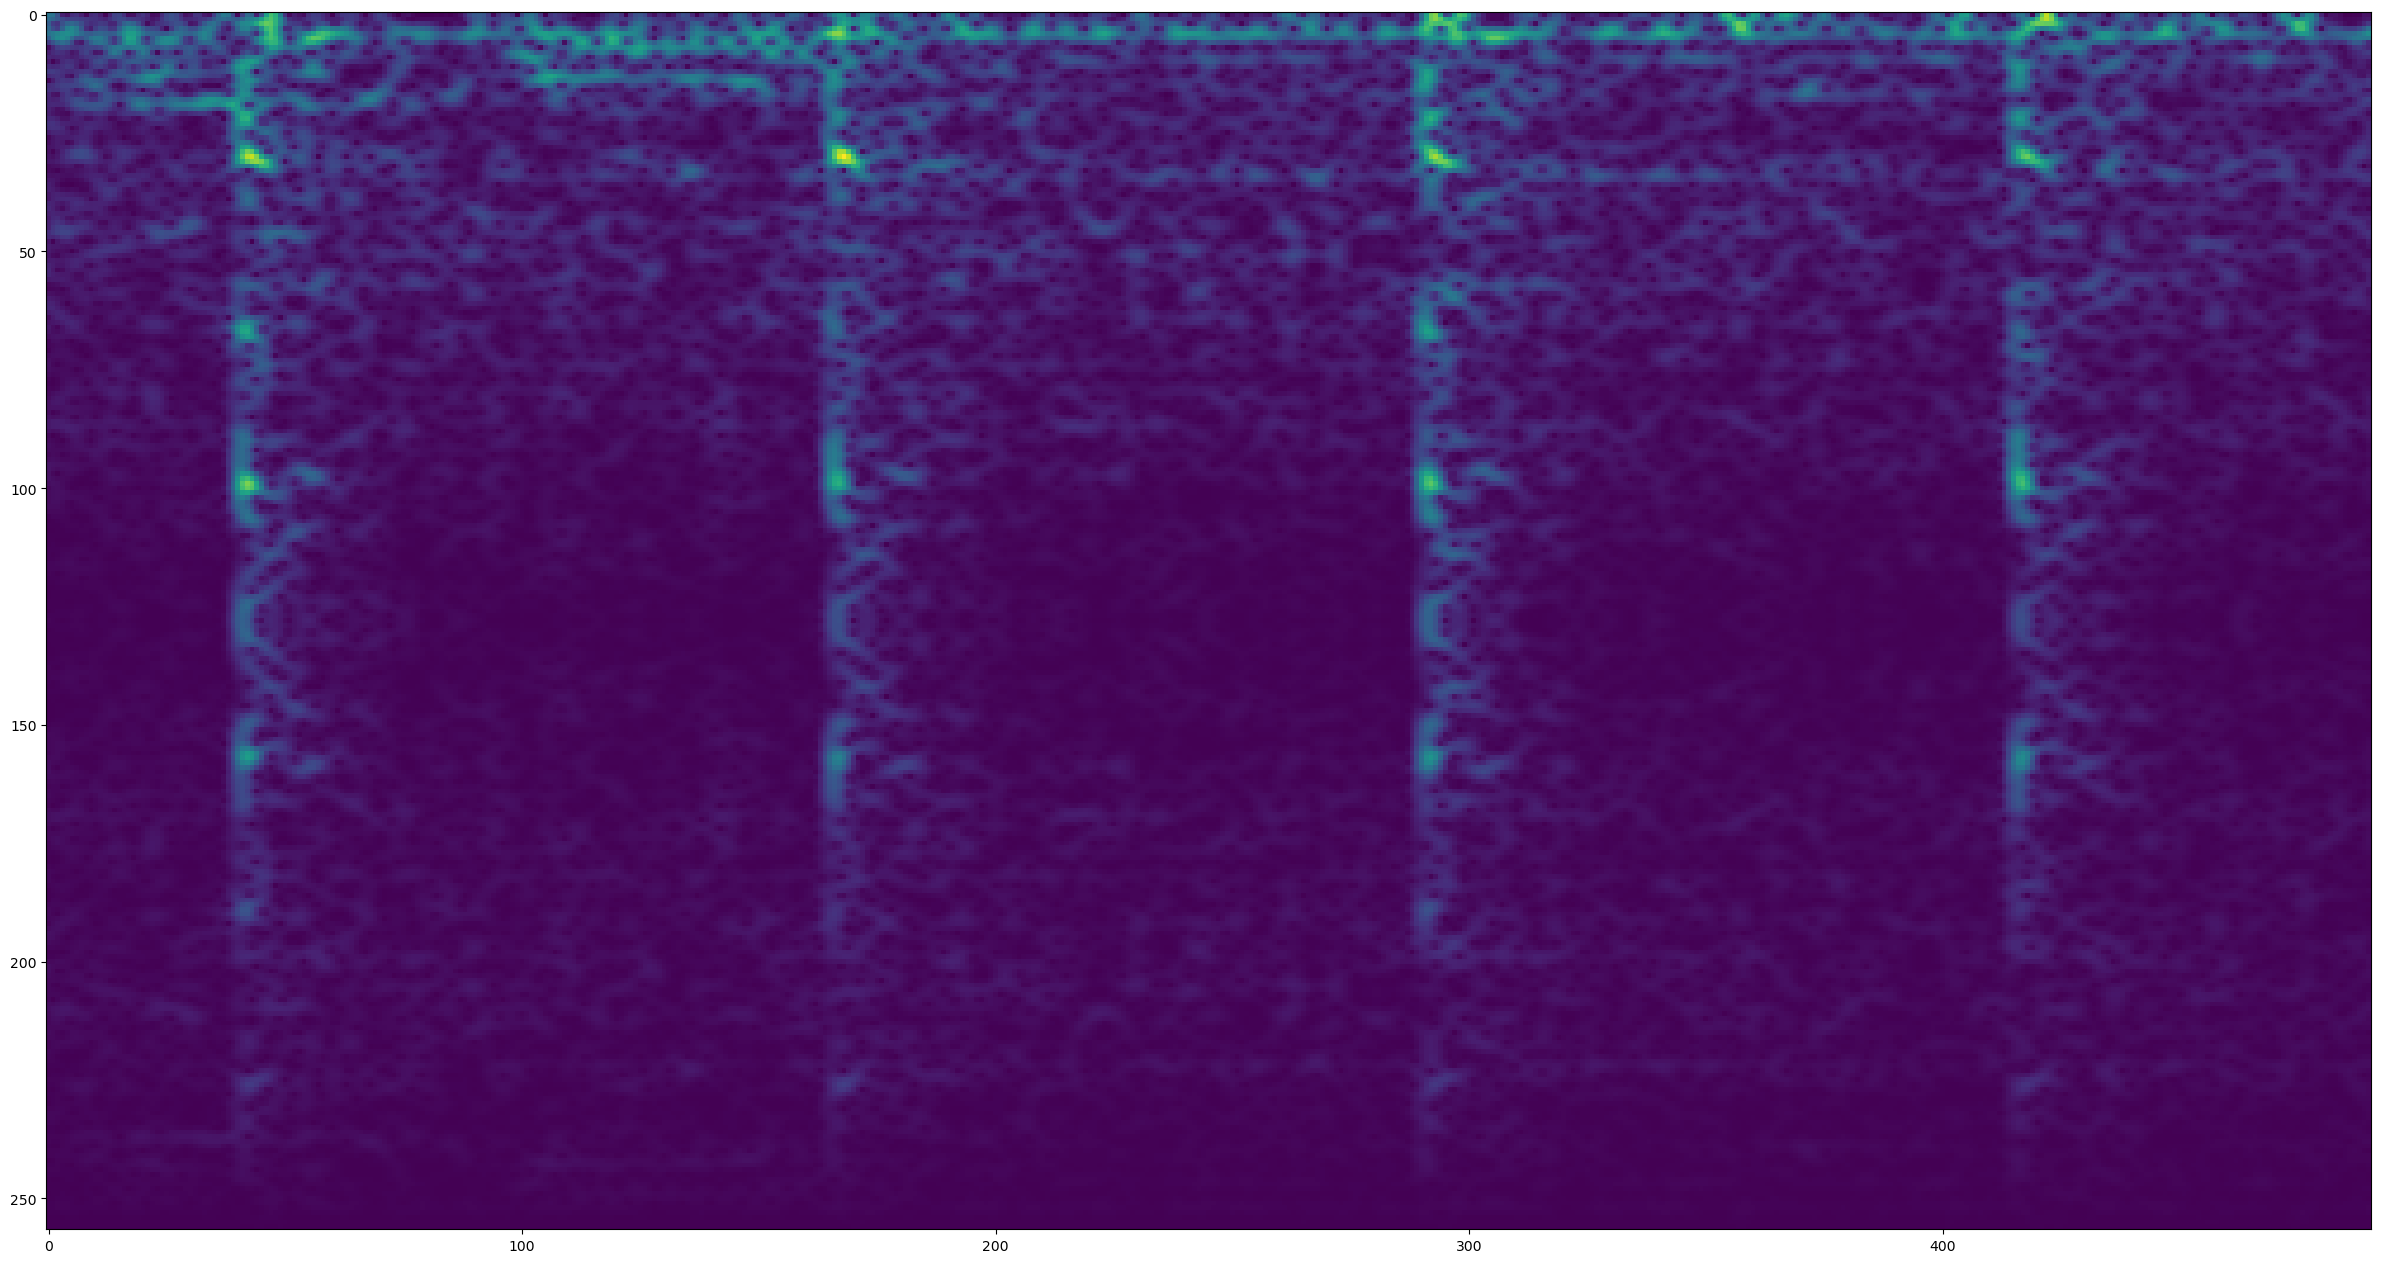

In [165]:
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

# 6. Create Training and Testing Partitions

## 6.1 Create a Tensorflow Data Pipeline

In [166]:
print(len(data))
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

236


## 6.2 Split into Training and Testing Partitions

In [167]:
len(data)*.8

12.0

In [168]:
train = data.take(int(len(data)*.8))
test = data.skip(int(len(data)*.8)).take(int(len(data)-len(data)*.8))

## 6.3 Test One Batch

In [169]:
samples, labels = train.as_numpy_iterator().next()

In [170]:
labels

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0.],
      dtype=float32)

In [171]:
samples.shape

(16, 491, 257, 1)

# 7. Build Deep Learning Model

## 7.1 Load Tensorflow Dependencies

In [172]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

## 7.2 Build Sequential Model, Compile and View Summary

In [173]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [174]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])

In [175]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 489, 255, 16)      160       
                                                                 
 conv2d_5 (Conv2D)           (None, 487, 253, 16)      2320      
                                                                 
 flatten_2 (Flatten)         (None, 1971376)           0         
                                                                 
 dense_4 (Dense)             (None, 128)               252336256 
                                                                 
 dense_5 (Dense)             (None, 1)                 129       
                                                                 
Total params: 252,338,865
Trainable params: 252,338,865
Non-trainable params: 0
_________________________________________________________________


## 7.3 Fit Model, View Loss and KPI Plots

In [176]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
12/12 [==============================] - 26s 2s/step - loss: 33.9141 - recall_2: 0.8146 - precision_2: 0.7935 - val_loss: 2.0331 - val_recall_2: 1.0000 - val_precision_2: 0.8537
Epoch 2/4
12/12 [==============================] - 22s 2s/step - loss: 1.0413 - recall_2: 0.8973 - precision_2: 0.8973 - val_loss: 0.4659 - val_recall_2: 1.0000 - val_precision_2: 0.8649
Epoch 3/4
12/12 [==============================] - 24s 2s/step - loss: 0.1626 - recall_2: 1.0000 - precision_2: 0.9416 - val_loss: 0.0102 - val_recall_2: 1.0000 - val_precision_2: 1.0000
Epoch 4/4
12/12 [==============================] - 22s 2s/step - loss: 0.0362 - recall_2: 0.9867 - precision_2: 1.0000 - val_loss: 0.0125 - val_recall_2: 1.0000 - val_precision_2: 1.0000


In [ ]:
# Save the model
tf.keras.models.save_model('audio_classification_model.h5')

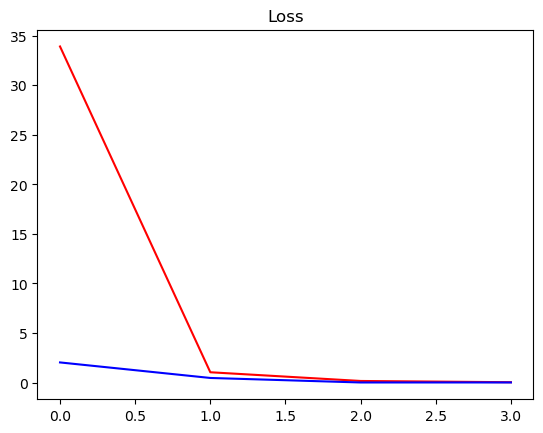

In [178]:
plt.title('Loss')
plt.plot(hist.history['loss'], 'r')
plt.plot(hist.history['val_loss'], 'b')
plt.show()

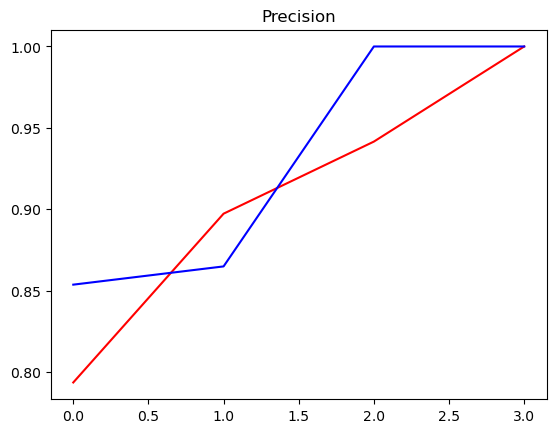

In [181]:
plt.title('Precision')
plt.plot(hist.history['precision_2'], 'r')
plt.plot(hist.history['val_precision_2'], 'b')
plt.show()

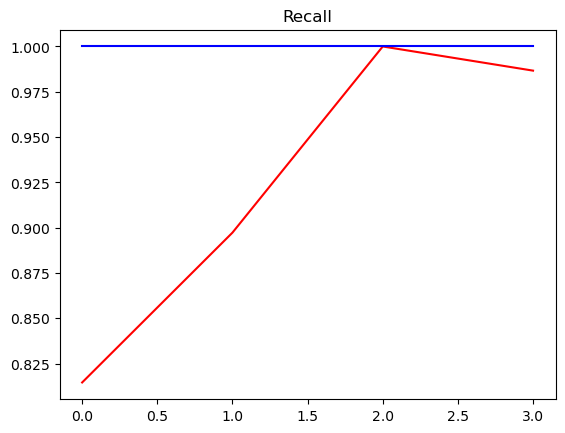

In [182]:
plt.title('Recall')
plt.plot(hist.history['recall_2'], 'r')
plt.plot(hist.history['val_recall_2'], 'b')
plt.show()

# 8. Make a Prediction on a Single Clip

## 8.1 Get One Batch and Make a Prediction

In [33]:
X_test, y_test = test.as_numpy_iterator().next()
print(X_test.shape)
print(y_test.shape)

(16, 491, 257, 1)
(16,)


In [34]:
yhat = model.predict(X_test)
yhat[:3]

1/1 [==============================] - 0s 401ms/step


array([[0.9998607],
       [0.999973 ],
       [0.9995586]], dtype=float32)

## 8.2 Convert Logits to Classes 

In [35]:
SCHWELLENWERT = 0.5
yhat = [1 if prediction > SCHWELLENWERT else 0 for prediction in yhat]
yhat

[1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1]

In [36]:
print(tf.math.reduce_sum(yhat))
print(tf.math.reduce_sum(y_test))

tf.Tensor(12, shape=(), dtype=int32)
tf.Tensor(12.0, shape=(), dtype=float32)


In [37]:
print(yhat)
print(y_test.astype(int))

[1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1]
[1 1 1 0 1 0 0 1 1 1 0 1 1 1 1 1]


# 9. Build Forest Parsing Functions

## 9.1 Load up WAVs

In [184]:
wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec2.wav')
#wav_path = os.path.join('./', 'audios', 'test', 'rec8.wav')

In [189]:
wav = load_wav_16k_mono(wav_path)
wav.shape

TensorShape([479232])

In [187]:
# print(wav)

import soundfile as sf
import numpy as np
import librosa
import scipy.signal as sps
signal, samplerate = sf.read(wav_path)
signal = np.float32(signal)
samplerate = np.int64(samplerate)
signal = librosa.resample(signal, orig_sr=samplerate, target_sr=160000)
# signal = sps.resample(signal, round(len(signal) * float(16000) / samplerate))
print(signal)



# import librosa
# y, sr = librosa.load(wav_path)
# print(y)

file_contents = tf.io.read_file(wav_path)
wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
wav = tf.squeeze(wav, axis=-1)
sample_rate = tf.cast(sample_rate, dtype=tf.int64)
wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
print(wav)


[-1.8298384e-03 -2.2112769e-03 -2.4619629e-03 ... -7.5164600e-05
 -8.6621789e-05 -8.7238208e-05]
tf.Tensor(
[-1.0593948e-08  3.1622552e-08 -5.6107652e-08 ...  9.1214088e-04
  2.2110064e-05 -2.8169787e-04], shape=(479232,), dtype=float32)


In [ ]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

In [190]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)

In [191]:
samples, index = audio_slices.as_numpy_iterator().next()

In [192]:
len(audio_slices)

29

In [43]:
samples.shape

(1, 16000)

In [47]:
print(tf.slice(wav,
               begin=[15997],
               size=[1]))
print(samples[0])
print(wav)

import numpy as np
t1 = wav.numpy()

print(np.array_equal(t1[:16000], samples[0]))

print(t1[:16000])
print(samples[0])

print(index)

tf.Tensor([0.00221841], shape=(1,), dtype=float32)
[-1.0593948e-08  3.1622552e-08 -5.6107652e-08 ...  2.2184055e-03
  3.0244896e-03  2.8425117e-03]
tf.Tensor(
[-1.0593948e-08  3.1622552e-08 -5.6107652e-08 ...  9.1214088e-04
  2.2110064e-05 -2.8169787e-04], shape=(479232,), dtype=float32)
True
[-1.0593948e-08  3.1622552e-08 -5.6107652e-08 ...  2.2184055e-03
  3.0244896e-03  2.8425117e-03]
[-1.0593948e-08  3.1622552e-08 -5.6107652e-08 ...  2.2184055e-03
  3.0244896e-03  2.8425117e-03]
[-1.0593948e-08]


## 9.2 Build Function to Convert Clips into Windowed Spectrograms

In [44]:
def preprocess_2(sample, index):
    sample = sample[0]
    zero_padding = tf.zeros([16000] - tf.shape(sample), dtype=tf.float32)
    wav = tf.concat([zero_padding, sample],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram

## 9.3 Convert Longer Clips into Windows and Make Predictions

In [45]:
audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=16000, sequence_stride=16000, batch_size=1)
audio_slices = audio_slices.map(preprocess_2)
audio_slices = audio_slices.batch(64)

In [46]:
yhat = model.predict(audio_slices)
yhat = [1 if prediction > 0.52 else 0 for prediction in yhat]
yhat

1/1 [==============================] - 0s 364ms/step


[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1]

## 9.4 Group Consecutive Detections

In [47]:
from itertools import groupby

In [48]:
yhat = [key for key, group in groupby(yhat)]
calls = tf.math.reduce_sum(yhat).numpy()

In [49]:
calls

1

# 10. Make Predictions

## 10.1 Loop over all recordings and make predictions

In [50]:
results = {}
for file in os.listdir(os.path.join('data', 'Forest Recordings')):
    FILEPATH = os.path.join('data','Forest Recordings', file)
    
    wav = load_mp3_16k_mono(FILEPATH)
    audio_slices = tf.keras.utils.timeseries_dataset_from_array(wav, wav, sequence_length=48000, sequence_stride=48000, batch_size=1)
    audio_slices = audio_slices.map(preprocess_mp3)
    audio_slices = audio_slices.batch(64)
    
    yhat = model.predict(audio_slices)
    
    results[file] = yhat

FileNotFoundError: [WinError 3] Das System kann den angegebenen Pfad nicht finden: 'data\\Forest Recordings'

In [ ]:
results

## 10.2 Convert Predictions into Classes

In [ ]:
class_preds = {}
for file, logits in results.items():
    class_preds[file] = [1 if prediction > 0.99 else 0 for prediction in logits]
class_preds

## 10.3 Group Consecutive Detections

In [ ]:
postprocessed = {}
for file, scores in class_preds.items():
    postprocessed[file] = tf.math.reduce_sum([key for key, group in groupby(scores)]).numpy()
postprocessed

# 11. Export Results

In [ ]:
import csv

In [ ]:
with open('results.csv', 'w', newline='') as f:
    writer = csv.writer(f, delimiter=',')
    writer.writerow(['recording', 'capuchin_calls'])
    for key, value in postprocessed.items():
        writer.writerow([key, value])